# Energy Hedge Ratio using Copula Models
## Mehrdad Heyrani (https://www.linkedin.com/in/mehrdad-heyrani/)
## Overview
This Google Colab notebook implements a comprehensive Copula Hedge Ratio Framework to determine optimal hedge ratios between power prices and natural gas (Henry Hub). It compares traditional Ordinary Least Squares (OLS) methods with a more sophisticated Copula-GARCH approach, accounting for time-varying rolling heat rates and non-linear dependencies between financial assets. The framework aims to help risk managers understand and quantify spark spread risk and identify optimal hedging strategies to minimize exposure to price fluctuations.

## Data
- **Source**: `EIA Power and Natural Gas price`
- **Content**: Includes Henry Hub natural gas prices and power prices for 10 hubs: ERCOT N, Mid C, Nepool MH, NYISO A/C/G/J, PJM WH, SP15.

## Methodology

### 1. Heat Rate Calculation
- **Implied HR_t**: Power_t / HH_t (MMBtu/MWh) on a daily basis.
- **Rolling HR**: A 90-day trailing median of implied heat rates, clipped between 3 and 30 MMBtu/MWh. This approach is robust to extreme price spikes and accounts for time-varying efficiency.
- **Spark Spread (SS_t)**: Calculated as Power_t − HR_t × HH_t ($/MWh), using the rolling heat rate.

### 2. OLS Hedge Ratios
- **Framework**: Based on Ederington (1979), using the relationship ΔSS_t = α + h* × ΔHH_t + ε_t.
- **Variants**:
  - **Constant HR**: Uses a long-run average heat rate, providing a static benchmark.
  - **Rolling HR**: Incorporates the time-varying rolling heat rate for a more dynamic hedge ratio.
- **Metrics**: Optimal hedge ratio (h*) and hedge effectiveness (HE, R²).

### 3. GARCH Marginals & PIT Transformation
- **Models**: AR(1)-GARCH(1,1)-t models are fitted to Henry Hub level changes and Spark Spread level changes for each power hub.
- **PIT Residuals**: Probability Integral Transform (PIT) residuals are extracted from the GARCH models, transforming them into uniformly distributed variables used for copula fitting.

### 4. Copula Fitting
- **Families**: Bivariate copulas (Gaussian, Student-t, Clayton, Gumbel, Frank, Rotated Gumbel) are fitted to the aligned PIT residuals of Spark Spread and Henry Hub.
- **Selection**: The best-fitting copula for each hub is identified based on the Akaike Information Criterion (AIC).

### 5. Copula-GARCH Optimal Hedge Ratios
- **Simulation**: Monte Carlo simulations (10,000 scenarios) are used to generate correlated future price changes based on the fitted copulas.
- **Revenue Calculation**: Revenue scenarios are generated for a grid of hedge ratios, considering the last observed rolling heat rate.
- **Risk Measures**: Optimal hedge ratios (h*) are determined for various risk objectives:
  - Minimum Variance (MinVar)
  - Maximum Hedge Effectiveness (MaxHE)
  - Minimum Conditional Value at Risk (MinCFaR at 95%)
  - Minimum Conditional Expected Shortfall (MinCCFaR)

## Key Findings






In [1]:
!pip install arch statsmodels scipy pandas numpy matplotlib seaborn openpyxl -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 24.5 MB/s eta 0:00:00


In [2]:
from google.colab import files

print("Please upload the price file from EIA:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f"User uploaded file '{fn}' with length {len(uploaded[fn])} bytes")

Please upload the price file from EIA:


Saving Power_Price_Realized_2021-2026.xlsx to Power_Price_Realized_2021-2026.xlsx
User uploaded file 'Power_Price_Realized_2021-2026.xlsx' with length 194054 bytes


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════
# IMPORTS & GLOBAL CONFIG
# ╚══════════════════════════════════════════════════════════════════════════════
import warnings; warnings.filterwarnings("ignore")
import os, itertools
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats, optimize
from scipy.stats import norm, t as t_dist
from scipy.special import gammaln
import statsmodels.api as sm
from arch import arch_model

plt.rcParams.update({
    "figure.dpi": 150, "font.family": "DejaVu Sans",
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelsize": 9,  "xtick.labelsize": 8,
    "ytick.labelsize": 8, "axes.spines.top": False,
    "axes.spines.right": False, "legend.fontsize": 8,
    "figure.facecolor": "white",
})

# ── Global configuration — change these to explore different settings ─────────
# ← filename with SPACES as it appears in Colab after upload
DATA_FILE  = "Power Price Realized 2021-2026.xlsx"

# ── Auto-locate the file (works in Colab, local Jupyter, and direct run) ──────
import pathlib

def find_data_file(filename):
    """

    """
    # Build a list of candidate names covering both spaces and underscores
    # (Colab sometimes preserves spaces; local saves often use underscores)
    alt_name   = filename.replace(" ", "_")   # spaces → underscores
    alt_name2  = filename.replace("_", " ")   # underscores → spaces
    candidates = list(dict.fromkeys([filename, alt_name, alt_name2]))

    search_paths = []
    for name in candidates:
        search_paths += [
            pathlib.Path(name),
            pathlib.Path("/content") / name,
            pathlib.Path("/content/drive/MyDrive") / name,
            pathlib.Path.home() / name,
            pathlib.Path.home() / "Downloads" / name,
        ]
    for p in search_paths:
        if p.exists():
            return str(p)

    # File not found — print a clear upload instruction for Colab
    raise FileNotFoundError(
        f"\n\n{'='*60}\n"
        f"  File not found: {filename}\n"
        f"{'='*60}\n"
        f"  To upload in Google Colab:\n"
        f"    1. Click the folder icon (📁) in the left sidebar\n"
        f"    2. Click the upload icon (⬆) at the top of the Files panel\n"
        f"    3. Select  {filename}  from your computer\n"
        f"    4. Wait for the upload to complete (the file appears in /content/)\n"
        f"    5. Re-run this cell\n\n"
        f"  OR mount Google Drive and place the file there:\n"
        f"    from google.colab import drive\n"
        f"    drive.mount('/content/drive')\n"
        f"    DATA_FILE = '/content/drive/MyDrive/{filename}'\n"
        f"{'='*60}\n"
    )
OUT_FOLDER = "/content/"
os.makedirs(OUT_FOLDER, exist_ok=True)

# Heat rate rolling window (days) — tune per market
HR_WINDOW    = 90      # ← primary window used in copula model
HR_CLIP_LOW  = 3.0     # MMBtu/MWh — floor (below = data artefact / negative price)
HR_CLIP_HIGH = 30.0    # MMBtu/MWh — cap  (above = extreme spike, not representative)

# Copula simulation
N_SIM        = 10_000
CFAR_ALPHA   = 0.05    # 95% CFaR/CCFaR
H_GRID       = np.linspace(-3, 3, 601)  # default/reference grid only — Cell 6 now builds an
                                         # adaptive per-hub grid centered on the closed-form
                                         # MinVar solution (see copula_hedge_ratios), since a
                                         # single fixed range can't fit every hub's natural scale

# Power hubs to include in analysis
POWER_HUBS   = ["NYISO A", "NYISO C", "NYISO G", "NYISO J",
                 "Nepool MH", "PJM WH", "ERCOT North", "SP15"]

# Hub colours for charts
HUB_COLORS = {
    "NYISO A":    "#e41a1c", "NYISO C":    "#377eb8",
    "NYISO G":    "#4daf4a", "NYISO J":    "#984ea3",
    "Nepool MH":  "#ff7f00", "PJM WH":     "#a65628",
    "ERCOT North":"#f781bf", "SP15":       "#999999",
}

print("✓ Imports & config complete")
print(f"  HR window : {HR_WINDOW} days  |  clip [{HR_CLIP_LOW}, {HR_CLIP_HIGH}]")
print(f"  Hubs      : {POWER_HUBS}")

# ╔══════════════════════════════════════════════════════════════════════════════
#  DATA LOADING & HEAT RATE COMPUTATION
# ╚══════════════════════════════════════════════════════════════════════════════
print("\n── 1. Loading Data & Computing Rolling Heat Rates ──")

DATA_FILE_PATH = find_data_file(DATA_FILE)
print(f"  ✓ File found: {DATA_FILE_PATH}")
df = pd.read_excel(DATA_FILE_PATH, sheet_name="Flat Price")
df["Date"]     = pd.to_datetime(df["Date"])
df             = df.dropna(subset=["Henry_Hub"]).sort_values("Date").reset_index(drop=True)
df["HH"]       = df["Henry_Hub"]   # shorthand

N_OBS = len(df)
print(f"  {N_OBS:,} daily obs  {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"  Hubs available: {[c for c in df.columns if c != 'Date']}")

# ── ROLLING HEAT RATE ─────────────────────────────────────────────────────────
# Implied daily heat rate = Power_t / HH_t  (MMBtu/MWh)
# We clip to [HR_CLIP_LOW, HR_CLIP_HIGH] before rolling to prevent extreme
# spike days (e.g. Texas Feb-2021, New England Jan-2024) from distorting the
# rolling estimate used for hedging decisions.


print(f"\n  Computing HR_t = rolling {HR_WINDOW}-day median(Power/HH), "
      f"clipped to [{HR_CLIP_LOW}, {HR_CLIP_HIGH}] MMBtu/MWh")

hr_raw = {}   # unclipped daily implied heat rate per hub
hr_roll= {}   # rolling median heat rate used in hedging

for h in POWER_HUBS:
    if h not in df.columns:
        continue
    # Daily implied heat rate
    raw             = df[h] / df["HH"]
    hr_raw[h]       = raw
    # Clip before rolling: exclude data artefacts and extreme spike hours
    raw_clip        = raw.clip(lower=HR_CLIP_LOW, upper=HR_CLIP_HIGH)
    # Rolling median over HR_WINDOW days, require at least 30 obs
    rolling_med     = raw_clip.rolling(window=HR_WINDOW, min_periods=30).median()
    hr_roll[h]      = rolling_med
    df[f"HR_raw_{h}"]  = raw
    df[f"HR_roll_{h}"] = rolling_med

hr_df   = pd.DataFrame(hr_roll, index=df.index)
hr_raw_df = pd.DataFrame(hr_raw, index=df.index)

# ── Summary statistics ────────────────────────────────────────────────────────
print(f"\n  Rolling {HR_WINDOW}-day median heat rate summary (MMBtu/MWh):")
print(f"  {'Hub':<14} {'Mean':>8} {'Std':>7} {'Min':>7} {'P25':>7} "
      f"{'Med':>7} {'P75':>7} {'Max':>7} {'Last':>8}")
print("  " + "─"*73)

for h in POWER_HUBS:
    if h not in hr_roll: continue
    s = hr_roll[h].dropna()
    print(f"  {h:<14} {s.mean():>8.2f} {s.std():>7.2f} {s.min():>7.2f} "
          f"{s.quantile(.25):>7.2f} {s.median():>7.2f} "
          f"{s.quantile(.75):>7.2f} {s.max():>7.2f} "
          f"{s.iloc[-1]:>8.2f}")

# ── Spark spread using rolling heat rate ─────────────────────────────────────
print(f"\n  Spark spread SS_t = Power_t − HR_roll_t × HH_t  ($/MWh):")
print(f"  {'Hub':<14} {'Mean SS':>10} {'Std SS':>9} {'P5':>9} "
      f"{'Median':>9} {'P95':>9} {'NegSS%':>9}")
print("  " + "─"*65)

ss_df = pd.DataFrame(index=df.index)
for h in POWER_HUBS:
    if f"HR_roll_{h}" not in df.columns: continue
    ss              = df[h] - df[f"HR_roll_{h}"] * df["HH"]
    ss_df[h]        = ss
    df[f"SS_{h}"]   = ss
    valid           = ss.dropna()
    neg_pct         = (valid < 0).mean() * 100
    print(f"  {h:<14} {valid.mean():>10.2f} {valid.std():>9.2f} "
          f"{valid.quantile(.05):>9.2f} {valid.median():>9.2f} "
          f"{valid.quantile(.95):>9.2f} {neg_pct:>8.1f}%")

# ╔══════════════════════════════════════════════════════════════════════════════
#  METHOD 1: OLS HEDGE RATIO (static & rolling-HR variants)
# ╚══════════════════════════════════════════════════════════════════════════════
print("\n── 2. Method 1: OLS Minimum-Variance Hedge Ratio ──")
print("""
  Framework — Ederington (1979):
  ΔSS_t = α + h* × ΔHH_t + ε_t
  where ΔSS = change in spark spread, ΔHH = change in gas price
  h* (OLS) = Cov(ΔSS, ΔHH) / Var(ΔHH)  = ρ × σ_SS / σ_HH
  HE = R² = proportion of spark spread variance hedged by gas forwards

  Two variants:
    Constant HR: use long-run average heat rate (ignores intraperiod changes)
    Rolling HR : use HR_roll_t at each date (correct for time-varying efficiency)
""")

def ols_hedge_ratio(ss_returns, hh_returns):
    """OLS h*, HE (R²), correlation, and OLS model object."""
    valid = np.isfinite(ss_returns) & np.isfinite(hh_returns)
    if valid.sum() < 10:
        return dict(h_ols=np.nan, HE=np.nan, corr=np.nan, n=0)
    y = ss_returns[valid]; x = hh_returns[valid]
    X = sm.add_constant(x)
    lm = sm.OLS(y, X).fit()
    corr = np.corrcoef(y, x)[0, 1]
    return dict(h_ols=lm.params[1], HE=lm.rsquared, corr=corr,
                n=valid.sum(), model=lm)

def ols_robustness_check(ss_returns, hh_returns, pct=1.0):
    """
    DIAGNOSTIC ONLY — does not replace the textbook Ederington h* above.
    Linear min-variance hedge ratios are well known to be dominated by a
    handful of extreme co-movement days on fat-tailed commodity data
    (Cov(ΔSS,ΔHH) is just a sum, so one huge cross-product term can swing
    it). This reports:
      h_wins        : h* after winsorizing both series at [pct, 100-pct]
      loo_shift_pct : % change in h* if the single most extreme ΔHH day
                      is dropped (leave-one-out influence)
    Large gaps between h_ols and h_wins, or a large loo_shift_pct, mean
    the "headline" h* is not a stable estimate — treat the copula/rank-
    based hedge ratio as the more reliable number in that case.
    """
    valid = np.isfinite(ss_returns) & np.isfinite(hh_returns)
    y = ss_returns[valid]; x = hh_returns[valid]
    if len(y) < 30 or np.var(x) == 0:
        return dict(h_wins=np.nan, loo_shift_pct=np.nan)

    lo_y, hi_y = np.percentile(y, pct), np.percentile(y, 100 - pct)
    lo_x, hi_x = np.percentile(x, pct), np.percentile(x, 100 - pct)
    y_w = np.clip(y, lo_y, hi_y); x_w = np.clip(x, lo_x, hi_x)
    h_wins = np.cov(y_w, x_w)[0, 1] / np.var(x_w)

    h_full = np.cov(y, x)[0, 1] / np.var(x)
    worst  = np.argmax(np.abs(x - x.mean()))      # single most extreme ΔHH day
    mask   = np.ones(len(x), dtype=bool); mask[worst] = False
    h_loo  = np.cov(y[mask], x[mask])[0, 1] / np.var(x[mask])
    loo_shift_pct = 100 * (h_loo - h_full) / h_full if h_full != 0 else np.nan
    return dict(h_wins=h_wins, loo_shift_pct=loo_shift_pct)

# Log returns for HH (diagnostic use) and $ level change (used by the copula, Cell 4/5/6)
df["r_HH"] = np.log(df["HH"] / df["HH"].shift(1))
df["d_HH"] = df["HH"].diff()

ols_const_hr = {}
ols_roll_hr  = {}
fragile_hubs = []   # hubs where OLS h* is not stable to a single extreme day

print(f"  {'Hub':<14} {'h*(const HR)':>13} {'HE const':>10} "
      f"{'h*(roll HR)':>13} {'HE roll':>9} {'ρ(SS,HH)':>10} "
      f"{'h*_wins(1%)':>12} {'LOO Δ%':>8}")
print("  " + "─"*100)

for h in POWER_HUBS:
    if h not in df.columns: continue

    # ── Constant HR variant ──
    # Use long-run average HR (fixed for entire history)
    hr_const  = hr_raw[h].clip(HR_CLIP_LOW, HR_CLIP_HIGH).median()
    ss_const  = df[h] - hr_const * df["HH"]
    r_ss_const = ss_const.diff()       # first difference (level changes)
    r_hh_lvl   = df["HH"].diff()
    res_const  = ols_hedge_ratio(r_ss_const.values, r_hh_lvl.values)
    ols_const_hr[h] = {**res_const, "hr_const": hr_const}

    # ── Rolling HR variant ──
    if f"HR_roll_{h}" not in df.columns:
        ols_roll_hr[h] = {"h_ols": np.nan, "HE": np.nan, "corr": np.nan}
        continue
    ss_roll   = df[f"SS_{h}"]          # already uses rolling HR
    r_ss_roll = ss_roll.diff()
    res_roll  = ols_hedge_ratio(r_ss_roll.values, r_hh_lvl.values)
    ols_roll_hr[h] = {**res_roll, "hr_used": f"roll{HR_WINDOW}d"}

    # ── Robustness diagnostic on the rolling-HR variant ──
    robust = ols_robustness_check(r_ss_roll.values, r_hh_lvl.values, pct=1.0)
    ols_roll_hr[h].update(robust)
    is_fragile = (np.isfinite(robust["loo_shift_pct"]) and abs(robust["loo_shift_pct"]) > 20)
    if is_fragile:
        fragile_hubs.append(h)

    h_c = res_const.get("h_ols", np.nan)
    he_c= res_const.get("HE",    np.nan)
    h_r = res_roll.get("h_ols",  np.nan)
    he_r= res_roll.get("HE",     np.nan)
    corr= res_roll.get("corr",   np.nan)
    flag = "  ⚠" if is_fragile else ""
    print(f"  {h:<14} {h_c:>13.4f} {he_c:>10.4f} "
          f"{h_r:>13.4f} {he_r:>9.4f} {corr:>10.4f} "
          f"{robust['h_wins']:>12.4f} {robust['loo_shift_pct']:>7.1f}%{flag}")

if fragile_hubs:
    print(f"\n  ⚠  {len(fragile_hubs)} hub(s) [{', '.join(fragile_hubs)}] have an OLS h* that moves "
          f">20% if a single extreme ΔHH day is dropped.")
    print( "     These OLS estimates are NOT stable point estimates — a handful of cold-snap/")
    print( "     price-spike days dominate the covariance. Prefer the copula-based h* (Cell 6),")
    print( "     which uses rank dependence (Kendall's τ) and is far less sensitive to the exact")
    print( "     magnitude of a few extreme days.")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════
# GARCH MARGINALS + PIT (per hub pair with HH)
# ╚══════════════════════════════════════════════════════════════════════════════
print("\n── 3. GARCH(1,1)-t Marginals & PIT Transformation ──")

def fit_garch_t(series_dec, label="", index=None, target_scale=10.0):
    """
    Fit AR(1)-GARCH(1,1)-t

    """
    s = pd.Series(series_dec, index=index).dropna()
    if len(s) < 100:
        return None, None, None, None, None
    raw_std = s.std()
    if not np.isfinite(raw_std) or raw_std == 0:
        return None, None, None, None, None
    scale = target_scale / raw_std          # auto-scale to a well-conditioned magnitude
    s_scaled = s * scale
    try:
        am  = arch_model(s_scaled, mean="AR", lags=1, vol="GARCH",
                         p=1, q=1, dist="t", rescale=False)
        res = am.fit(disp="off", show_warning=False,
                     options={"maxiter": 200})
        cond_vol = np.asarray(res.conditional_volatility, dtype=float) / scale  # back to original $ units
        cond_vol = np.where(np.isfinite(cond_vol), cond_vol, np.nanmean(cond_vol))
        nu  = next((float(res.params[k])
                    for k in ["nu","eta","df"]
                    if k in res.params.index), 5.0)
        std_resid = pd.Series(res.std_resid, index=s.index).dropna()
        u_pit_vals = np.clip(t_dist.cdf(std_resid.values, df=nu), 1e-6, 1-1e-6)
        u_pit = pd.Series(u_pit_vals, index=std_resid.index)   # date-indexed!
        return res, cond_vol, u_pit, nu, scale
    except Exception as e:
        print(f"    GARCH failed for {label}: {e}")
        return None, None, None, None, None

def get_param(res, *keys, default=np.nan):
    for k in keys:
        if k in res.params.index:
            return float(res.params[k])
    return default

# Fit GARCH-t marginal on Henry Hub $ LEVEL CHANGES (ΔHH_t) — NOT log returns.
#

res_hh, cond_vol_hh, u_hh_full, nu_hh, scale_hh = fit_garch_t(df["d_HH"], "Henry Hub")

if res_hh is not None:
    print(f"  Henry Hub  ω={get_param(res_hh,'omega'):.5f}  "
          f"α={get_param(res_hh,'alpha[1]'):.4f}  "
          f"β={get_param(res_hh,'beta[1]'):.4f}  "
          f"ν={nu_hh:.2f}  "
          f"AnnVol=${np.nanmean(cond_vol_hh)*np.sqrt(252):.3f}/MMBtu")

# Fit GARCH-t marginal on SPARK SPREAD $ LEVEL CHANGES (ΔSS_t) per hub —

garch_fits  = {}    # hub → dict(res, cond_vol, u_pit [date-indexed], nu, ss_chg, ...)
print()
print(f"  {'Hub':<14} {'ω':>9} {'α':>8} {'β':>8} {'α+β':>8} "
      f"{'ν':>7} {'AnnVol($/MWh)':>14}")
print("  " + "─"*70)

for h in POWER_HUBS:
    if f"SS_{h}" not in df.columns:
        continue
    d_ss = df[f"SS_{h}"].diff()   # $/MWh day-over-day spark spread change

    res_ss, cond_vol_ss, u_ss, nu_ss, scale_ss = fit_garch_t(d_ss, h)
    if res_ss is None:
        continue

    last_px = float(df[h].dropna().iloc[-1])

    garch_fits[h] = {
        "res":        res_ss,
        "cond_vol":   cond_vol_ss,        # $/MWh conditional vol of the spark spread
        "u_pit":      u_ss,               # date-indexed PIT residuals for copula fitting
        "nu":         nu_ss,
        "ss_chg":     d_ss.dropna().values,     # $/MWh changes, for the MC back-transform
        "last_px":    last_px,
    }
    omega = get_param(res_ss, "omega")
    alpha = get_param(res_ss, "alpha[1]")
    beta  = get_param(res_ss, "beta[1]")
    ann_v = np.nanmean(cond_vol_ss) * np.sqrt(252)    # annualised $/MWh vol
    print(f"  {h:<14} {omega:>9.5f} {alpha:>8.4f} {beta:>8.4f} "
          f"{alpha+beta:>8.4f} {nu_ss:>7.2f} {ann_v:>13.2f}")

# ╔══════════════════════════════════════════════════════════════════════════════
# COPULA FITTING (bivariate: spark spread × Henry Hub)
# ╚══════════════════════════════════════════════════════════════════════════════
print("\n── 4. Bivariate Copula Fitting: Spark Spread × Henry Hub ──")

# ── Copula log-likelihoods ────────────────────────────────────────────────────
def gaussian_nll(params, u, v):
    rho = np.clip(params[0], -0.999, 0.999); eps = 1e-8
    x   = norm.ppf(np.clip(u, eps, 1-eps))
    y   = norm.ppf(np.clip(v, eps, 1-eps))
    Q   = x**2 + y**2 - 2*rho*x*y
    return np.sum(0.5*np.log(1-rho**2) + Q/(2*(1-rho**2)) - (x**2+y**2)/2)

def student_nll(params, u, v):
    rho, nu = params; eps = 1e-8
    rho = np.clip(rho, -0.999, 0.999); nu = max(nu, 2.01)
    x   = t_dist.ppf(np.clip(u, eps, 1-eps), df=nu)
    y   = t_dist.ppf(np.clip(v, eps, 1-eps), df=nu)
    Q   = (x**2 + y**2 - 2*rho*x*y) / (1-rho**2)
    ll  = (gammaln((nu+2)/2) - gammaln(nu/2)
           - np.log(nu*np.pi) - 0.5*np.log(1-rho**2)
           - ((nu+2)/2)*np.log(1 + Q/nu))
    return -np.sum(ll - t_dist.logpdf(x, df=nu) - t_dist.logpdf(y, df=nu))

def clayton_nll(params, u, v):
    th = max(params[0], 1e-4); eps = 1e-8
    u_ = np.clip(u, eps, 1-eps); v_ = np.clip(v, eps, 1-eps)
    ll = np.log(1+th) + (-1-th)*np.log(u_*v_) - (1/th+2)*np.log(u_**(-th)+v_**(-th)-1)
    return -np.sum(ll[np.isfinite(ll)])

def gumbel_nll(params, u, v):
    """
    Gumbel copula log-density (CORRECTED):
      c(u,v;θ) = [C(u,v)/(uv)] · (xy)^(θ-1) · A^(1/θ-2) · [θ-1+A^(1/θ)]
      where x=-ln(u), y=-ln(v), A = x^θ+y^θ, C = exp(-A^(1/θ))

    """
    th = max(params[0], 1.001); eps = 1e-12
    u_ = np.clip(u, eps, 1-eps); v_ = np.clip(v, eps, 1-eps)
    lu = (-np.log(u_))**th; lv = (-np.log(v_))**th
    A  = np.maximum(lu+lv, eps)
    ll = (-A**(1/th) + (1/th-2)*np.log(A)
          + np.log(A**(1/th)+th-1)
          + (th-1)*(np.log(-np.log(u_))+np.log(-np.log(v_)))
          - np.log(u_) - np.log(v_))
    return -np.sum(ll[np.isfinite(ll)])

def frank_nll(params, u, v):
    """
    Frank copula log-density (corrected formula):
      c(u,v) = θ · A · e^{-θ(u+v)} / (A + B·C)²
    where A=expm1(-θ) [<0], B=expm1(-θu) [<0], C=expm1(-θv) [<0].
    log c = log|θ| + log|A| - θ(u+v) - 2·log|A+B·C|
    Previous version had wrong denominator (A - B·C/A)² instead of (A+B·C)².
    """
    th = params[0]; eps = 1e-8
    if abs(th) < eps: return 1e10
    u_ = np.clip(u, eps, 1-eps); v_ = np.clip(v, eps, 1-eps)
    A   = np.expm1(-th)          # e^{-θ}-1  < 0 for θ>0
    B   = np.expm1(-th * u_)     # e^{-θu}-1 < 0
    C   = np.expm1(-th * v_)     # e^{-θv}-1 < 0
    den = A + B * C              # < 0 for θ>0, u,v∈(0,1)
    ll  = (np.log(np.abs(th)) + np.log(np.abs(A))
           - th * (u_ + v_)
           - 2 * np.log(np.maximum(np.abs(den), eps)))
    return -np.sum(ll[np.isfinite(ll)])


def rot_gumbel_nll(params, u, v):
    """
    Rotated Gumbel (180°) = survival Gumbel = lower-tail dependent copula.
    c_rot(u,v) = c_Gumbel(1-u, 1-v; θ).
    Captures scenarios where both gas and power fall simultaneously.
    """
    return gumbel_nll(params, 1 - u, 1 - v)


def tau_from_copula(fam, par):
    if fam in ("Gaussian", "Student-t"): return 2*np.arcsin(par)/np.pi
    if fam == "Clayton":                 return par/(par+2)
    if fam in ("Gumbel", "Rot.Gumbel"): return 1 - 1/par
    if fam == "Frank":
        if abs(par) < 1e-6: return 0.0
        from scipy.integrate import quad
        d1, _ = quad(lambda t: t/(np.exp(t)-1), 0, abs(par))
        return 1 - 4/par*(1 - d1/par)
    return np.nan



COPULA_SPECS = [
    ("Gaussian",   gaussian_nll,   [0.5],      [(-0.999, 0.999)],            1),
    ("Student-t",  student_nll,    [0.5, 5.0], [(-0.999, 0.999),(2.01, 50)], 2),
    ("Clayton",    clayton_nll,    [1.0],       [(1e-4, 20)],                 1),
    ("Gumbel",     gumbel_nll,     [2.0],       [(1.001, 20)],                1),
    ("Frank",      frank_nll,      [2.0],       [(-100, 100)],                1),
    ("Rot.Gumbel", rot_gumbel_nll, [2.0],       [(1.001, 20)],                1),
]

def fit_all_copulas(u_ss, u_hh):
    """Fit all copula families, return AIC table and best fit."""
    mask = np.isfinite(u_ss) & np.isfinite(u_hh)
    u_s  = u_ss[mask]; u_h = u_hh[mask]
    results = []
    for fam, nll_fn, x0, bounds, npar in COPULA_SPECS:
        try:
            res = optimize.minimize(nll_fn, x0, args=(u_s, u_h),
                                    bounds=bounds, method="L-BFGS-B")
            ll  = -res.fun; aic = -2*ll + 2*npar
            par1 = res.x[0]
            par2 = res.x[1] if len(res.x) > 1 else 0.0
            tau  = tau_from_copula(fam, par1)
            results.append(dict(family=fam, par1=round(par1,4),
                                par2=round(par2,4), ll=round(ll,2),
                                aic=round(aic,2), tau=round(tau,4),
                                npar=npar, params=res.x))
        except Exception:
            pass
    results.sort(key=lambda x: x["aic"])
    return results

def simulate_copula(fam, params, n, seed=42):
    """Simulate n pairs from a fitted bivariate copula."""
    rng = np.random.default_rng(seed)
    p1  = params[0]; p2 = params[1] if len(params) > 1 else 0.0
    if fam == "Gaussian":
        rho = np.clip(p1, -0.999, 0.999)
        cov = np.array([[1,rho],[rho,1]])
        Z   = rng.multivariate_normal([0,0], cov, n)
        return norm.cdf(Z[:,0]), norm.cdf(Z[:,1])
    elif fam == "Student-t":
        rho = np.clip(p1,-0.999,0.999); nu = max(p2, 2.01)
        cov = np.array([[1,rho],[rho,1]])
        Z   = rng.multivariate_normal([0,0], cov, n)
        S   = rng.chisquare(nu, n)/nu
        Z   = Z/np.sqrt(S[:,None])
        return t_dist.cdf(Z[:,0],df=nu), t_dist.cdf(Z[:,1],df=nu)
    elif fam == "Clayton":
        th  = max(p1, 1e-4)
        u_  = rng.uniform(0,1,n); p_  = rng.uniform(0,1,n)
        v_  = u_*(p_**(-th/(1+th)) - 1 + u_**th)**(-1/th)
        return np.clip(u_,1e-6,1-1e-6), np.clip(v_,1e-6,1-1e-6)
    elif fam == "Gumbel":
        th  = max(p1, 1.001); alpha = 1/th
        B   = rng.uniform(-np.pi/2, np.pi/2, n)
        E   = rng.exponential(1.0, n)
        S   = (np.sin(alpha*(B+np.pi/2))/np.cos(B)**(1/alpha) *
               (np.cos(B-alpha*(B+np.pi/2))/E)**((1-alpha)/alpha))
        S   = np.maximum(S, 1e-300)
        E1  = rng.exponential(1.0, n); E2 = rng.exponential(1.0, n)
        return (np.clip(np.exp(-(E1/S)**(1/th)),1e-6,1-1e-6),
                np.clip(np.exp(-(E2/S)**(1/th)),1e-6,1-1e-6))
    elif fam == "Frank":
        u_  = rng.uniform(0,1,n); p_ = rng.uniform(0,1,n)
        em1 = np.expm1(-p1); emu = np.expm1(-p1*u_)
        den = 1.0 + emu*(1.0 - p_)
        v_  = -np.log1p(p_*em1/den) / p1
        return np.clip(u_,1e-6,1-1e-6), np.clip(v_,1e-6,1-1e-6)
    elif fam == "Rot.Gumbel":
        # Simulate Gumbel(θ) via Stable frailty, then rotate: (u,v)→(1-u,1-v)
        th = max(p1, 1.001); alpha = 1/th
        B  = rng.uniform(-np.pi/2, np.pi/2, n)
        E  = rng.exponential(1.0, n)
        S  = (np.sin(alpha*(B+np.pi/2))/np.cos(B)**(1/alpha)*
              (np.cos(B-alpha*(B+np.pi/2))/E)**((1-alpha)/alpha))
        S  = np.maximum(S, 1e-300)
        E1 = rng.exponential(1.0, n); E2 = rng.exponential(1.0, n)
        ug = np.clip(np.exp(-(E1/S)**(1/th)), 1e-6, 1-1e-6)
        vg = np.clip(np.exp(-(E2/S)**(1/th)), 1e-6, 1-1e-6)
        return 1-ug, 1-vg
    return rng.uniform(0,1,n), rng.uniform(0,1,n)

# ── Fit copulas per hub ───────────────────────────────────────────────────────


print(f"\n  {'Hub':<14}  {'Best Family':<12} {'par1':>8} {'par2':>8} "
      f"{'τ':>8} {'AIC':>10}")
print("  " + "─"*62)

for h in POWER_HUBS:
    if h not in garch_fits: continue
    if u_hh_full is None: continue
    u_ss  = garch_fits[h]["u_pit"]

    u_ss_al, u_hh_al = u_ss.align(u_hh_full, join="inner")
    u_ss_a = u_ss_al.values; u_hh_a = u_hh_al.values

    table  = fit_all_copulas(u_ss_a, u_hh_a)
    if not table: continue

    best   = table[0]
    copula_store[h] = {
        "best":   best,
        "table":  table,
        "u_ss":   u_ss_a,
        "u_hh":   u_hh_a,
    }
    print(f"  {h:<14}  {best['family']:<12} {best['par1']:>8.4f} "
          f"{best['par2']:>8.4f} {best['tau']:>8.4f} {best['aic']:>10.2f}")

# ╔══════════════════════════════════════════════════════════════════════════════
#  COPULA-GARCH OPTIMAL HEDGE RATIOS (per hub)
# ╚══════════════════════════════════════════════════════════════════════════════
print("\n── 5. Copula-GARCH Optimal Hedge Ratios ──")
print(f"""
  Monte Carlo: {N_SIM:,} scenarios per hub
  Back-transform: U[0,1] → empirical quantile of historical changes
                  (McNeil & Frey 2000 — uses full vol regime history)
  Heat rate: last observed rolling {HR_WINDOW}-day median HR_t
  Revenue(h) = ΔSS_t − h × HR_t × ΔHH_t  ($/MWh per unit generation)
  Risk measures: Variance · HE · CFaR ({100*(1-CFAR_ALPHA):.0f}%) · CCFaR
""")

def copula_hedge_ratios(h, hr_last):
    """
    For hub h, simulate revenue scenarios under each hedge ratio
    and compute Variance, HE, CFaR, CCFaR.
    Returns dict of optimal h* per risk measure.
    """
    if h not in copula_store or h not in garch_fits:
        return None

    best   = copula_store[h]["best"]
    u_ss_h = copula_store[h]["u_ss"]
    u_hh_h = copula_store[h]["u_hh"]

    # Simulate correlated U[0,1] from best copula
    sim_u_ss, sim_u_hh = simulate_copula(
        best["family"], best["params"], N_SIM, seed=42
    )

    # Back-transform U → price level changes ($/MWh and $/MMBtu)
    ss_hist  = garch_fits[h]["ss_chg"]         # $/MWh spark spread changes
    hh_hist  = df["HH"].diff().dropna().values # $/MMBtu HH changes

    # Clip both histories to remove extreme outlier days before quantile
    ss_clip = np.clip(ss_hist, np.percentile(ss_hist, 0.5),
                      np.percentile(ss_hist, 99.5))
    hh_clip = np.clip(hh_hist, np.percentile(hh_hist, 0.5),
                      np.percentile(hh_hist, 99.5))

    delta_ss  = np.quantile(ss_clip,  sim_u_ss)   # $/MWh change
    delta_hh  = np.quantile(hh_clip,  sim_u_hh)   # $/MMBtu change

    # Revenue change per MWh at hedge ratio h (hedge gas cost only):
    # ΔRevenue(h) = ΔSS − h × HR_t × ΔHH
    var_unhedged = np.var(delta_ss)
    if var_unhedged == 0:
        return None

    cov_ss_hh = np.cov(delta_ss, delta_hh)[0, 1]
    var_hh    = np.var(delta_hh)
    h_analytic = cov_ss_hh / (hr_last * var_hh) if var_hh > 0 else 0.0

    # CFaR/CCFaR are quantile-based with no closed form, so they still need
    # a grid search — but size that grid to this hub's own natural scale
    # (padded around h_analytic) instead of a single global range that may
    # be far too narrow for one hub and needlessly coarse for another.
    pad          = max(3.0, 2.5 * abs(h_analytic))
    h_grid_hub   = np.linspace(h_analytic - pad, h_analytic + pad, 601)

    metrics_h = {"Variance": [], "HE": [], "CFaR": [], "CCFaR": []}
    for hv in h_grid_hub:
        rev   = delta_ss - hv * hr_last * delta_hh
        var_v = np.var(rev)
        he_v  = 1 - var_v / var_unhedged
        cfar  = -np.percentile(rev, CFAR_ALPHA * 100)
        tail  = rev[rev < -cfar]
        ccfar = -tail.mean() if len(tail) > 0 else cfar
        metrics_h["Variance"].append(var_v)
        metrics_h["HE"].append(he_v)
        metrics_h["CFaR"].append(cfar)
        metrics_h["CCFaR"].append(ccfar)

    for k in metrics_h:
        metrics_h[k] = np.array(metrics_h[k])

    h_opt = {
        "MinVar":   h_analytic,     # closed-form — see above
        "MaxHE":    h_analytic,     # HE = 1 - Var(h)/Var(0) is maximised at the same h
        "MinCFaR":  h_grid_hub[np.argmin(metrics_h["CFaR"])],
        "MinCCFaR": h_grid_hub[np.argmin(metrics_h["CCFaR"])],
    }

    # Metrics at each optimal h
    def at_h(hv):
        rev   = delta_ss - hv * hr_last * delta_hh
        var_v = np.var(rev)
        cfar  = -np.percentile(rev, CFAR_ALPHA*100)
        tail  = rev[rev < -cfar]
        return dict(
            var=var_v,
            he=1-var_v/var_unhedged,
            cfar=cfar,
            ccfar=-tail.mean() if len(tail) > 0 else cfar,
        )


    nu_flag = (best["family"] == "Student-t" and best["par2"] < 4.0)

    return dict(
        h_opt=h_opt,
        curves=metrics_h,
        h_grid=h_grid_hub,          # this hub's own grid — for CFaR/CCFaR curves only
        metrics_at_opt={k: at_h(v) for k, v in h_opt.items()},
        delta_ss=delta_ss,
        delta_hh=delta_hh,
        hr_last=hr_last,
        family=best["family"],
        tau=best["tau"],
        nu=best.get("par2"),
        nu_flag=nu_flag,
        var_unhedged=var_unhedged,
    )

# Run for all hubs
copula_hr_results = {}

print(f"\n  {'Hub':<14} {'HR_last':>8} {'Copula':>10} {'τ':>7} "
      f"{'h*_Var':>8} {'h*_CFaR':>9} {'HE@Var%':>9} {'CFaR@h*':>10}")
print("  " + "─"*78)

for h in POWER_HUBS:
    if h not in copula_store: continue
    hr_last = df[f"HR_roll_{h}"].iloc[-1] if f"HR_roll_{h}" in df.columns else 10.0
    if np.isnan(hr_last): hr_last = 10.0

    result = copula_hedge_ratios(h, hr_last)
    if result is None: continue
    copula_hr_results[h] = result

    hv  = result["h_opt"]["MinVar"]
    hc  = result["h_opt"]["MinCFaR"]
    he_v= result["metrics_at_opt"]["MinVar"]["he"]
    cf  = result["metrics_at_opt"]["MinCFaR"]["cfar"]
    flag = "  ⚠ ν<4" if result["nu_flag"] else ""
    print(f"  {h:<14} {hr_last:>8.2f} {result['family']:>10} "
          f"{result['tau']:>7.4f} {hv:>8.4f} {hc:>9.4f} "
          f"{he_v*100:>8.1f}% {cf:>10.3f}{flag}")

if any(r["nu_flag"] for r in copula_hr_results.values()):
    low_nu_hubs = [h for h, r in copula_hr_results.items() if r["nu_flag"]]
    print(f"\n  ⚠  {len(low_nu_hubs)} hub(s) [{', '.join(low_nu_hubs)}] fit a Student-t copula with ν<4 "
          f"(barely above the ν>2 floor for finite variance).")
    print( "     For these hubs, Variance/MinVar is a numerically unstable criterion — a handful of")
    print( "     extreme simulated scenarios dominate the Monte-Carlo covariance. h*_CFaR/h*_CCFaR")
    print( "     (quantile-based, no dependence on 2nd moments) should be treated as primary for them.")

# ╔══════════════════════════════════════════════════════════════════════════════
# COMPARISON TABLE: OLS vs COPULA
# ╚══════════════════════════════════════════════════════════════════════════════
print("\n── 6. Full Comparison: OLS vs Copula Hedge Ratios ──")

print(f"\n  {'Hub':<14} {'HR_roll':>8} "
      f"{'OLS_const':>10} {'OLS_roll':>10} "
      f"{'Cop_Var':>9} {'Cop_CFaR':>10} "
      f"{'HE_OLS':>8} {'HE_Cop':>8} "
      f"{'Copula':>11}")
print("  " + "─"*100)

comparison = []
for h in POWER_HUBS:
    hr_l  = df[f"HR_roll_{h}"].iloc[-1] if f"HR_roll_{h}" in df.columns else np.nan
    h_olsc= ols_const_hr.get(h, {}).get("h_ols", np.nan)
    h_olsr= ols_roll_hr.get(h,  {}).get("h_ols", np.nan)
    he_ol = ols_roll_hr.get(h,  {}).get("HE",    np.nan)
    cr    = copula_hr_results.get(h, {})
    h_var = cr.get("h_opt", {}).get("MinVar",  np.nan)
    h_cfr = cr.get("h_opt", {}).get("MinCFaR", np.nan)
    he_cop= cr.get("metrics_at_opt", {}).get("MinVar", {}).get("he", np.nan)
    fam   = cr.get("family", "N/A")
    tau   = cr.get("tau", np.nan)

    print(f"  {h:<14} {hr_l:>8.2f} "
          f"{h_olsc:>10.4f} {h_olsr:>10.4f} "
          f"{h_var:>9.4f} {h_cfr:>10.4f} "
          f"{he_ol*100 if not np.isnan(he_ol) else np.nan:>7.1f}% "
          f"{he_cop*100 if not np.isnan(he_cop) else np.nan:>7.1f}% "
          f"{fam:>11}")
    comparison.append(dict(Hub=h, HR_roll=round(hr_l,2),
                           h_OLS_const=round(h_olsc,4),
                           h_OLS_roll=round(h_olsr,4),
                           h_Copula_Var=round(h_var,4),
                           h_Copula_CFaR=round(h_cfr,4),
                           HE_OLS_pct=round(he_ol*100,1) if not np.isnan(he_ol) else np.nan,
                           HE_Copula_pct=round(he_cop*100,1) if not np.isnan(he_cop) else np.nan,
                           Copula_Family=fam,
                           Tau=round(tau,4) if not np.isnan(tau) else np.nan))

comp_df = pd.DataFrame(comparison)
csv_path = os.path.join(OUT_FOLDER, "HedgeRatio_Comparison.csv")
comp_df.to_csv(csv_path, index=False)
print(f"\n  → CSV saved: {csv_path}")

✓ Imports & config complete
  HR window : 90 days  |  clip [3.0, 30.0]
  Hubs      : ['NYISO A', 'NYISO C', 'NYISO G', 'NYISO J', 'Nepool MH', 'PJM WH', 'ERCOT North', 'SP15']

── 1. Loading Data & Computing Rolling Heat Rates ──
  ✓ File found: Power_Price_Realized_2021-2026.xlsx
  1,916 daily obs  2021-03-01 → 2026-05-31
  Hubs available: ['ERCOT North', 'Mid C', 'Nepool MH', 'NYISO A', 'NYISO C', 'NYISO G', 'NYISO J', 'PJM WH', 'SP15', 'Henry_Hub', 'HH']

  Computing HR_t = rolling 90-day median(Power/HH), clipped to [3.0, 30.0] MMBtu/MWh

  Rolling 90-day median heat rate summary (MMBtu/MWh):
  Hub                Mean     Std     Min     P25     Med     P75     Max     Last
  ─────────────────────────────────────────────────────────────────────────
  NYISO A           10.96    3.48    4.12    8.66   10.20   13.89   19.54    11.22
  NYISO C           11.41    3.97    4.14    8.62   10.54   14.53   22.94    13.20
  NYISO G           13.47    3.45    8.98   10.33   13.03   15.47   24.

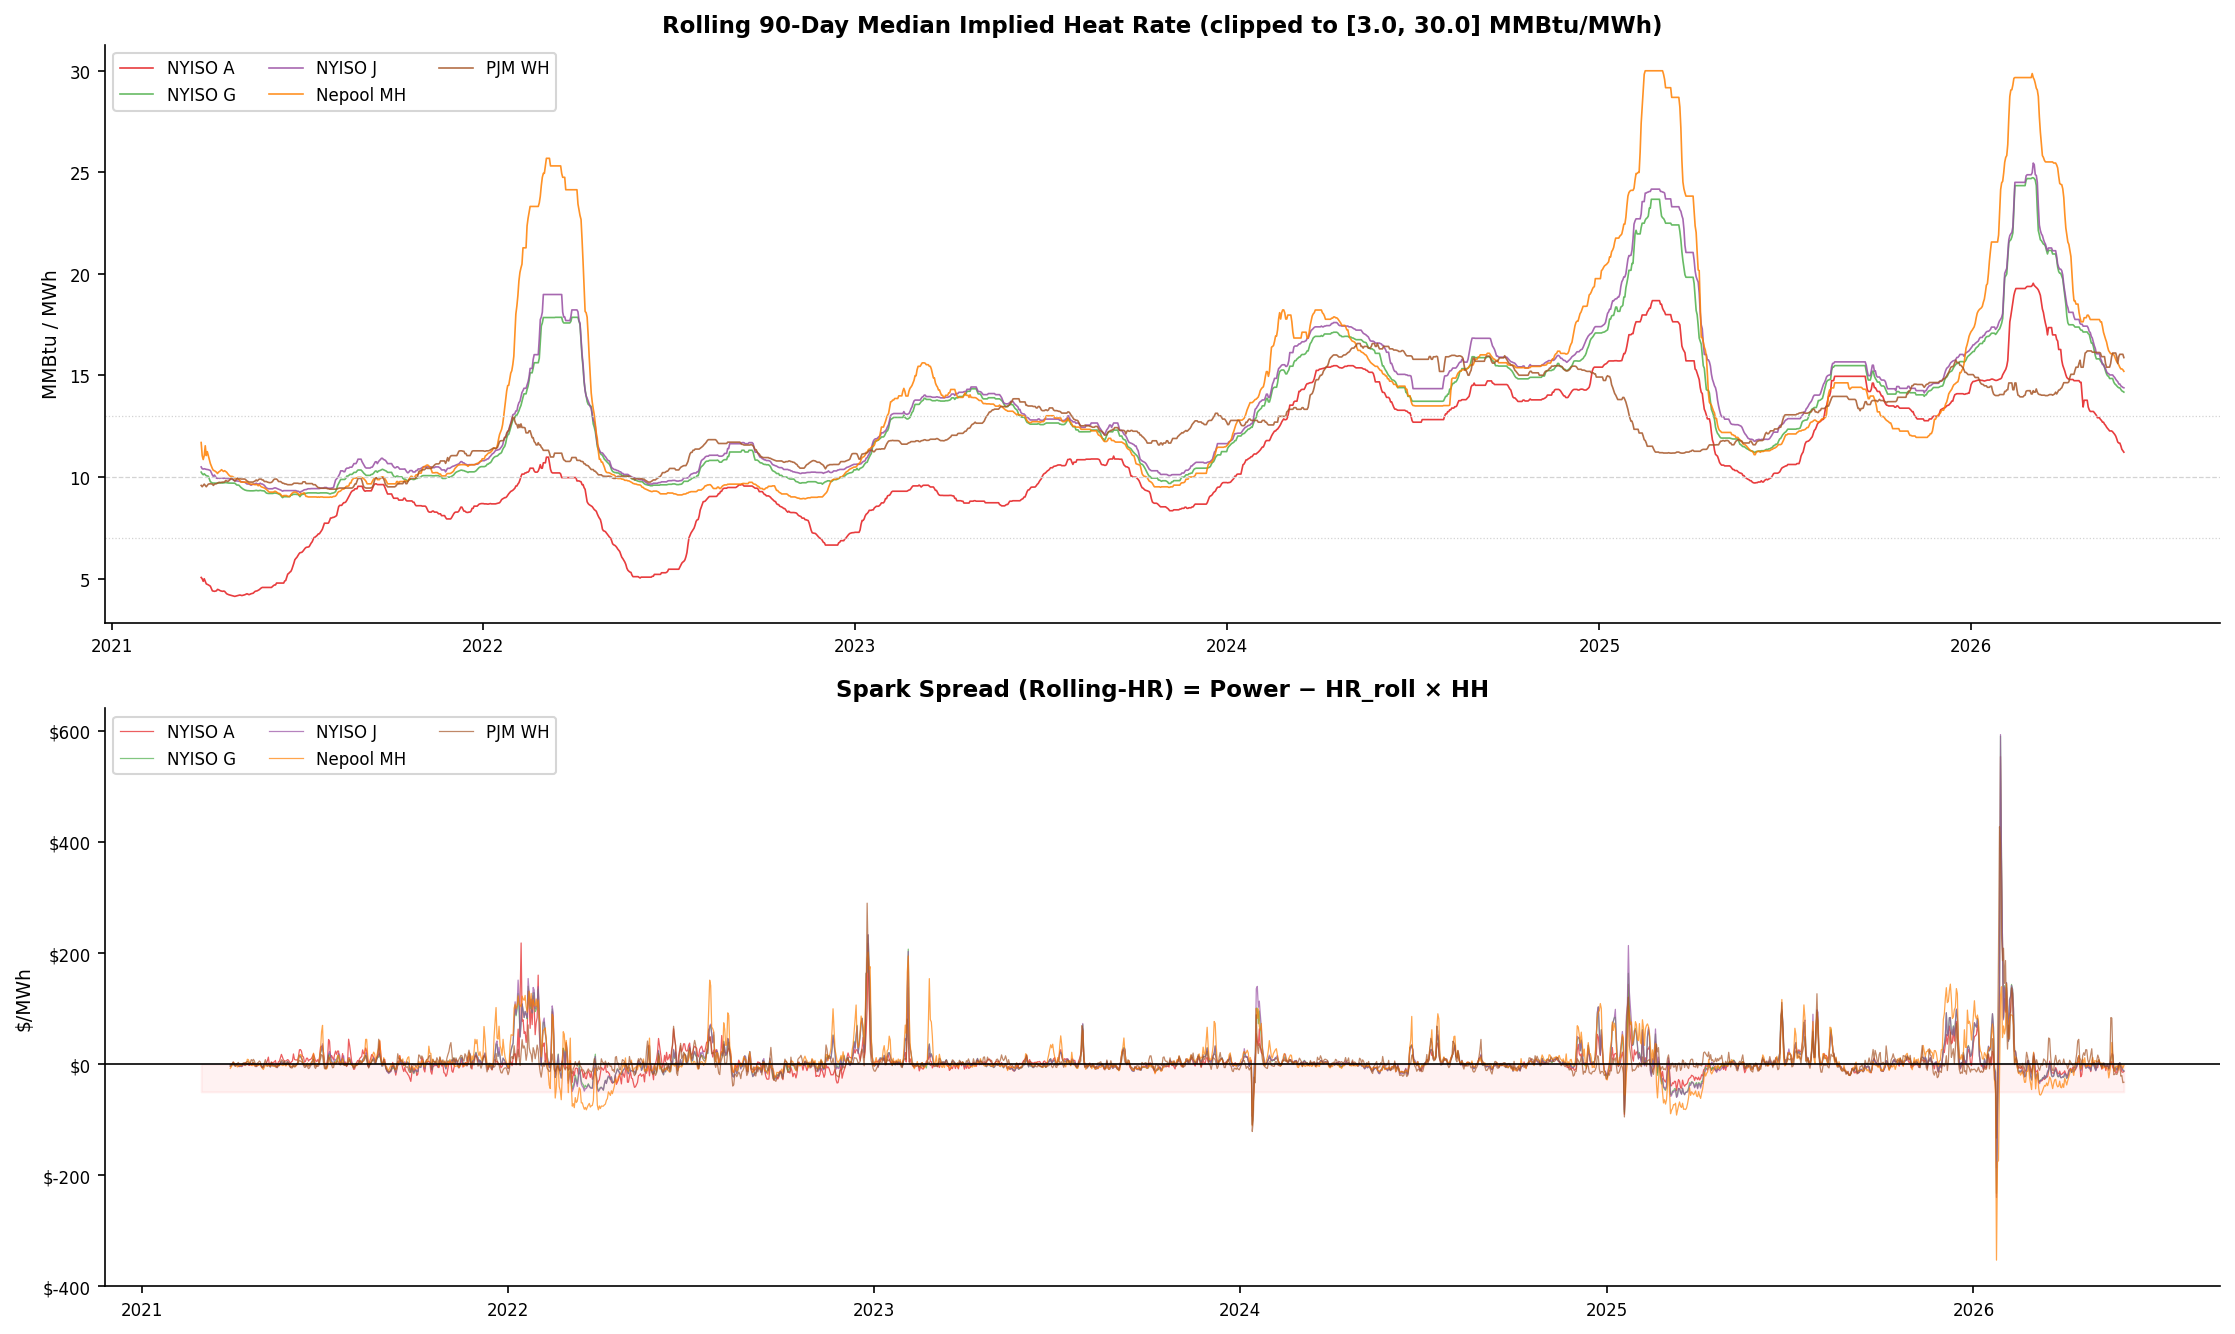

  → /content/HeatRate_SparkSpread.png


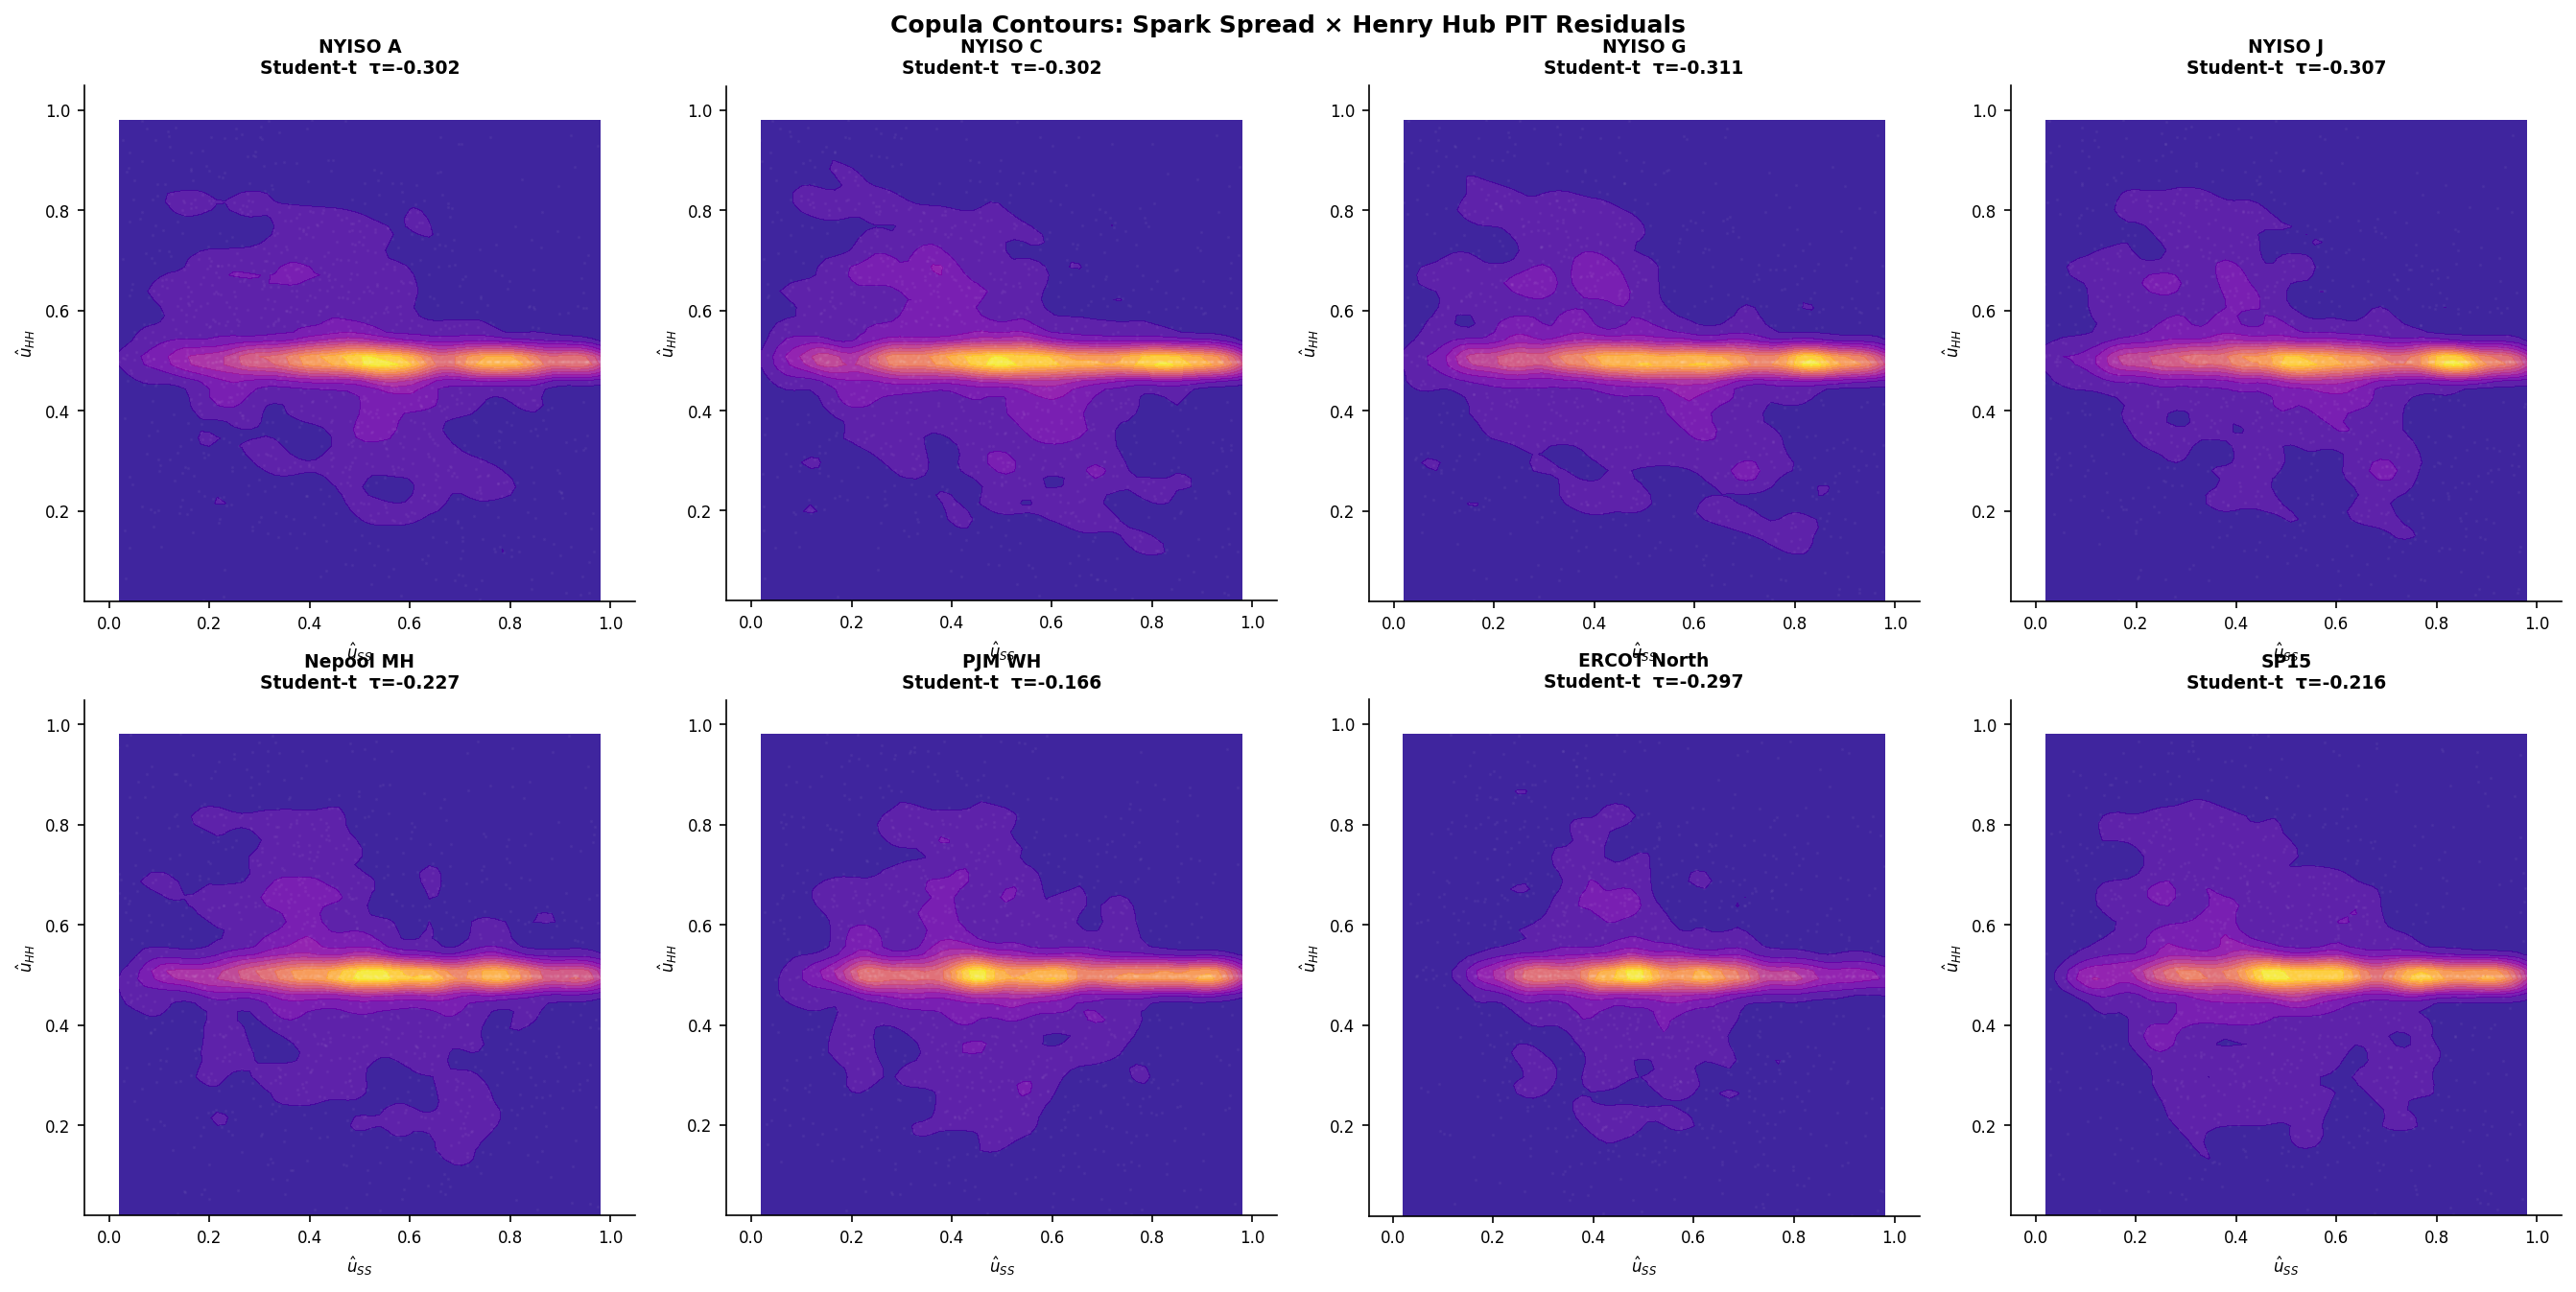

  → /content/Copula_Contours_AllHubs.png


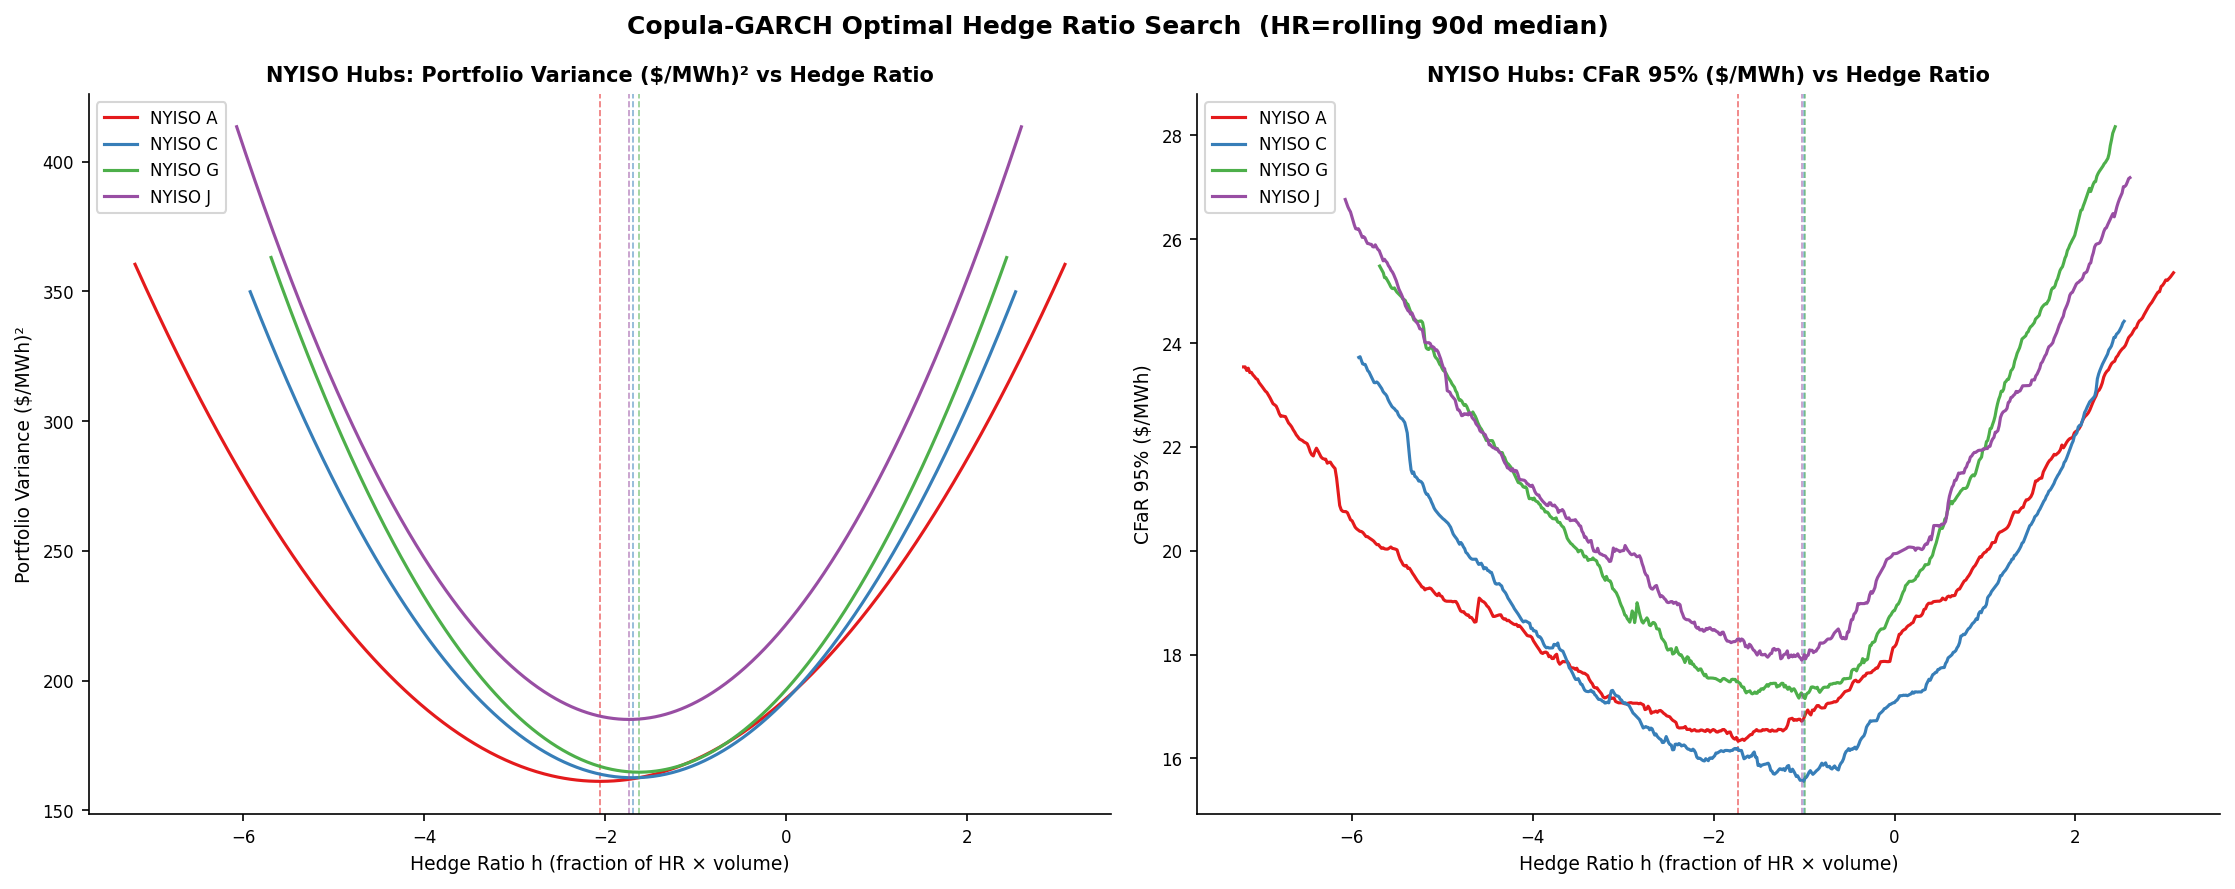

  → /content/HedgeRatio_Curves_NYISO.png


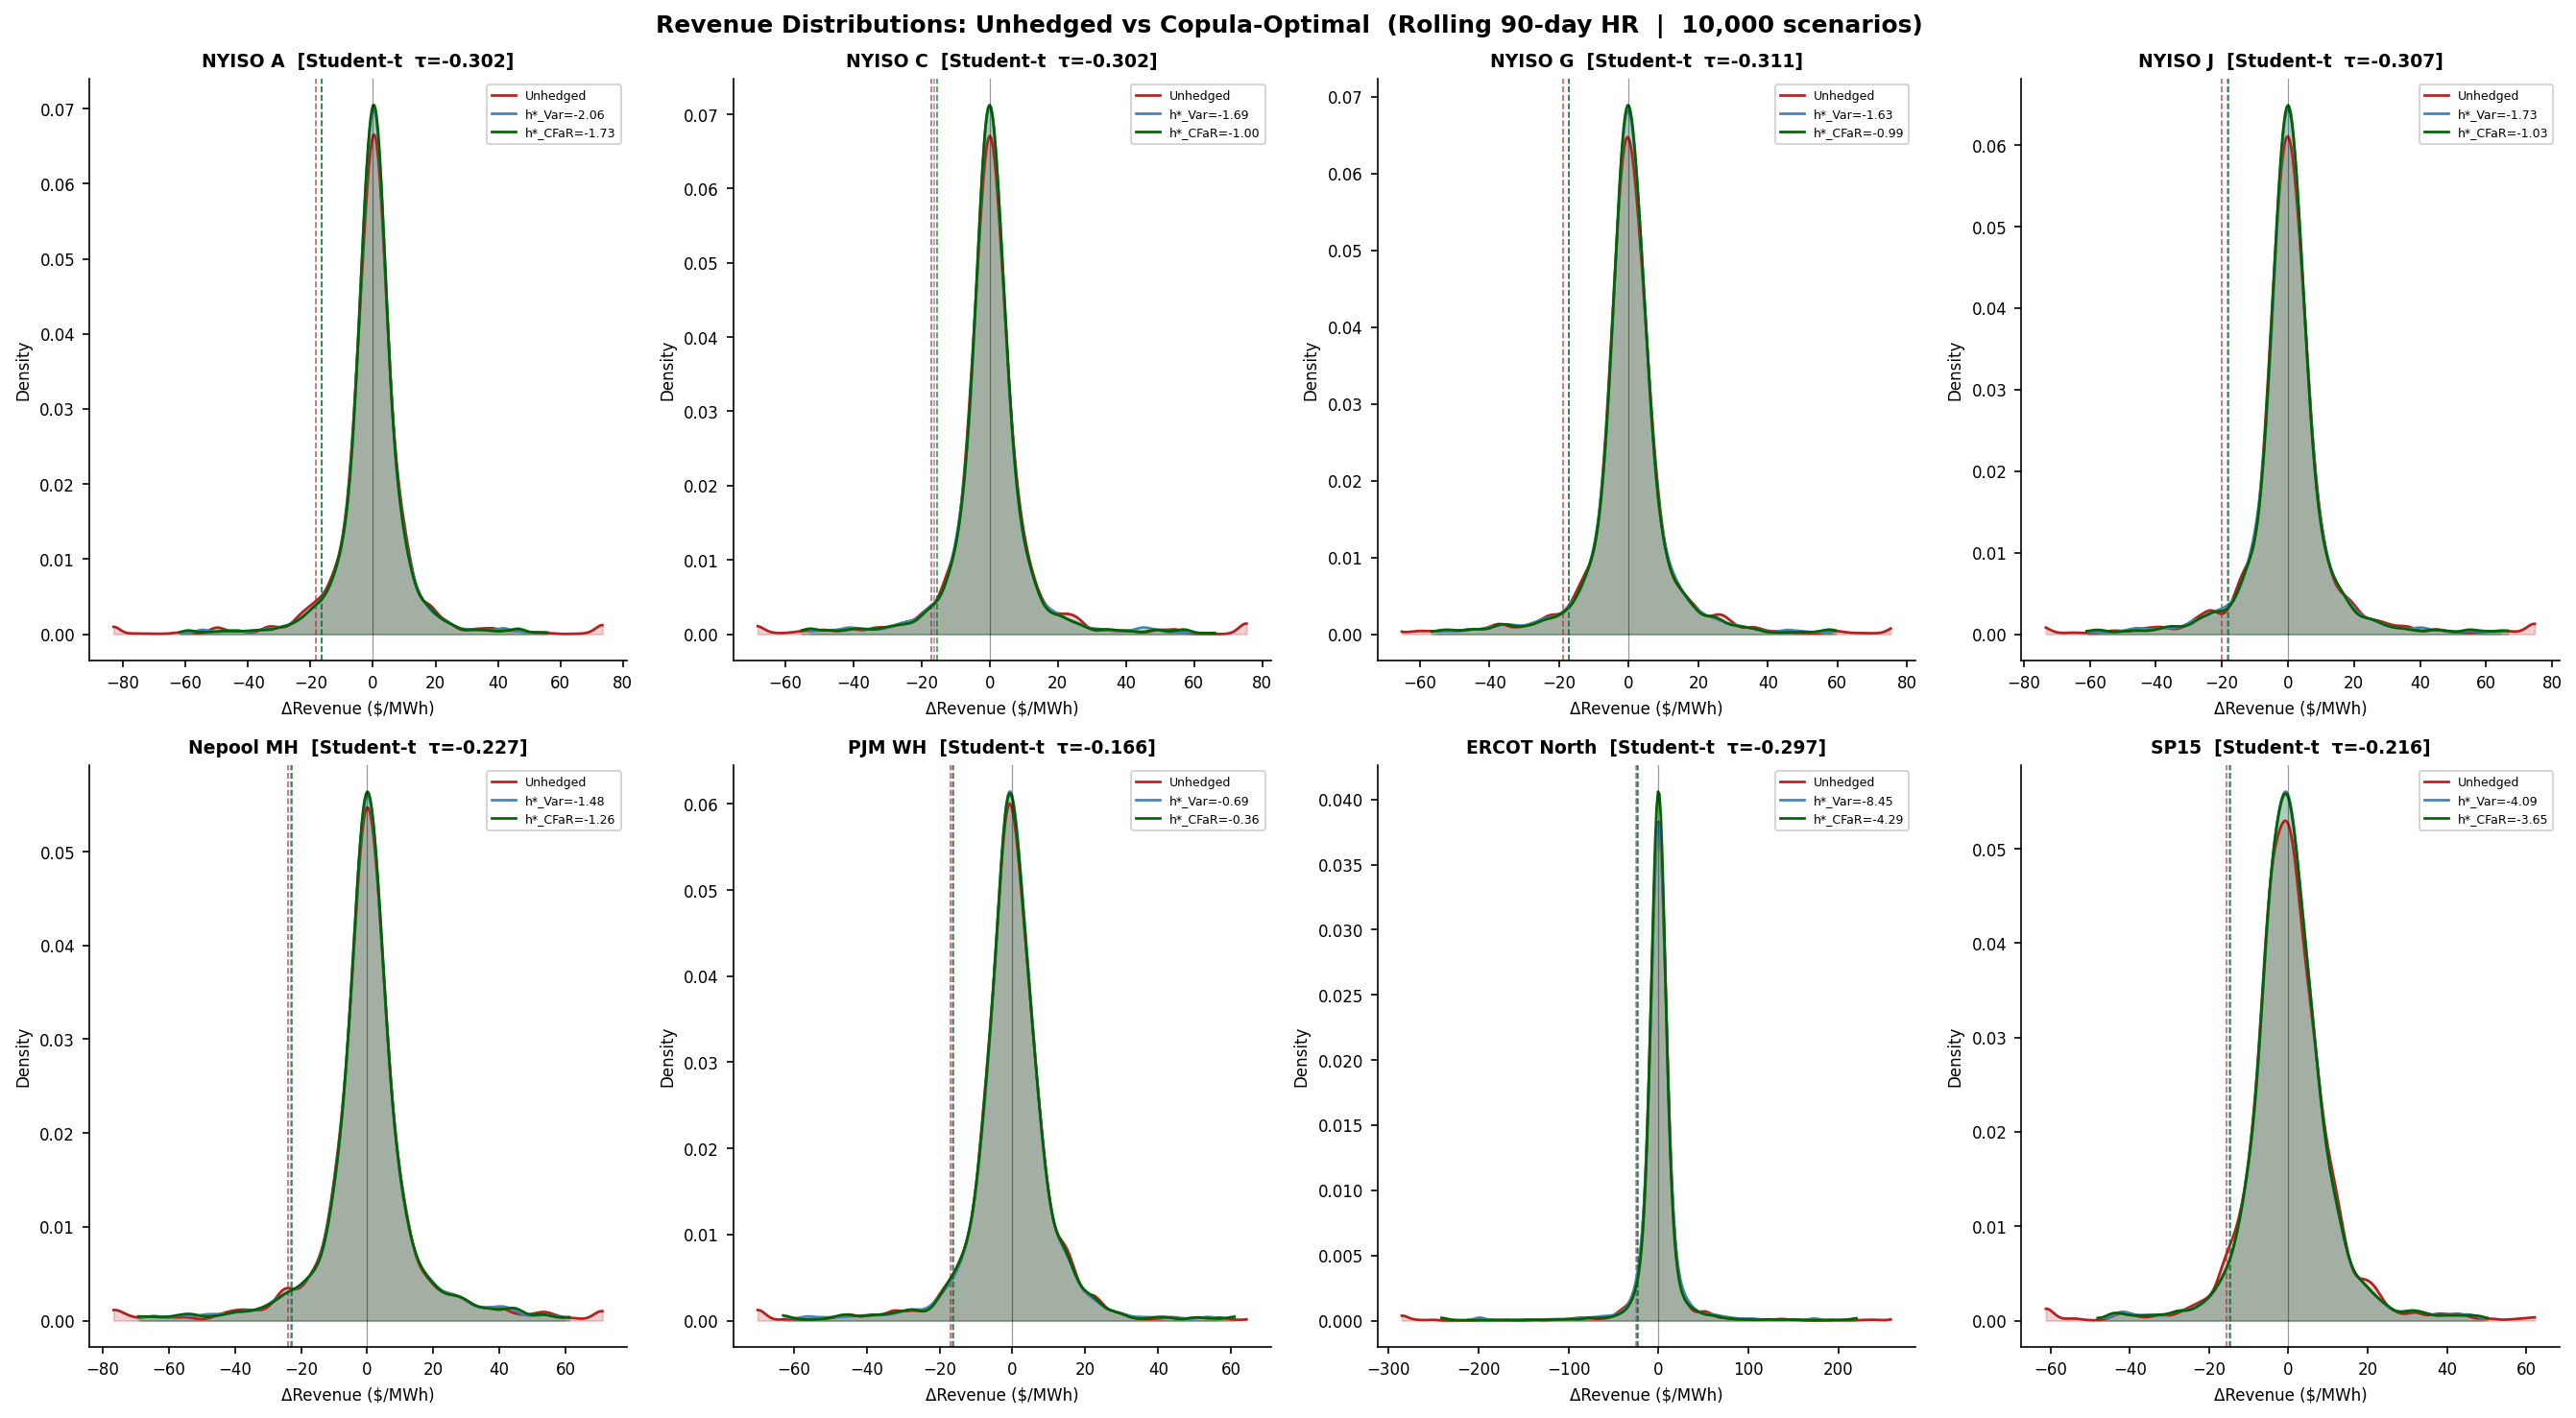

  → /content/Revenue_Distributions_AllHubs.png


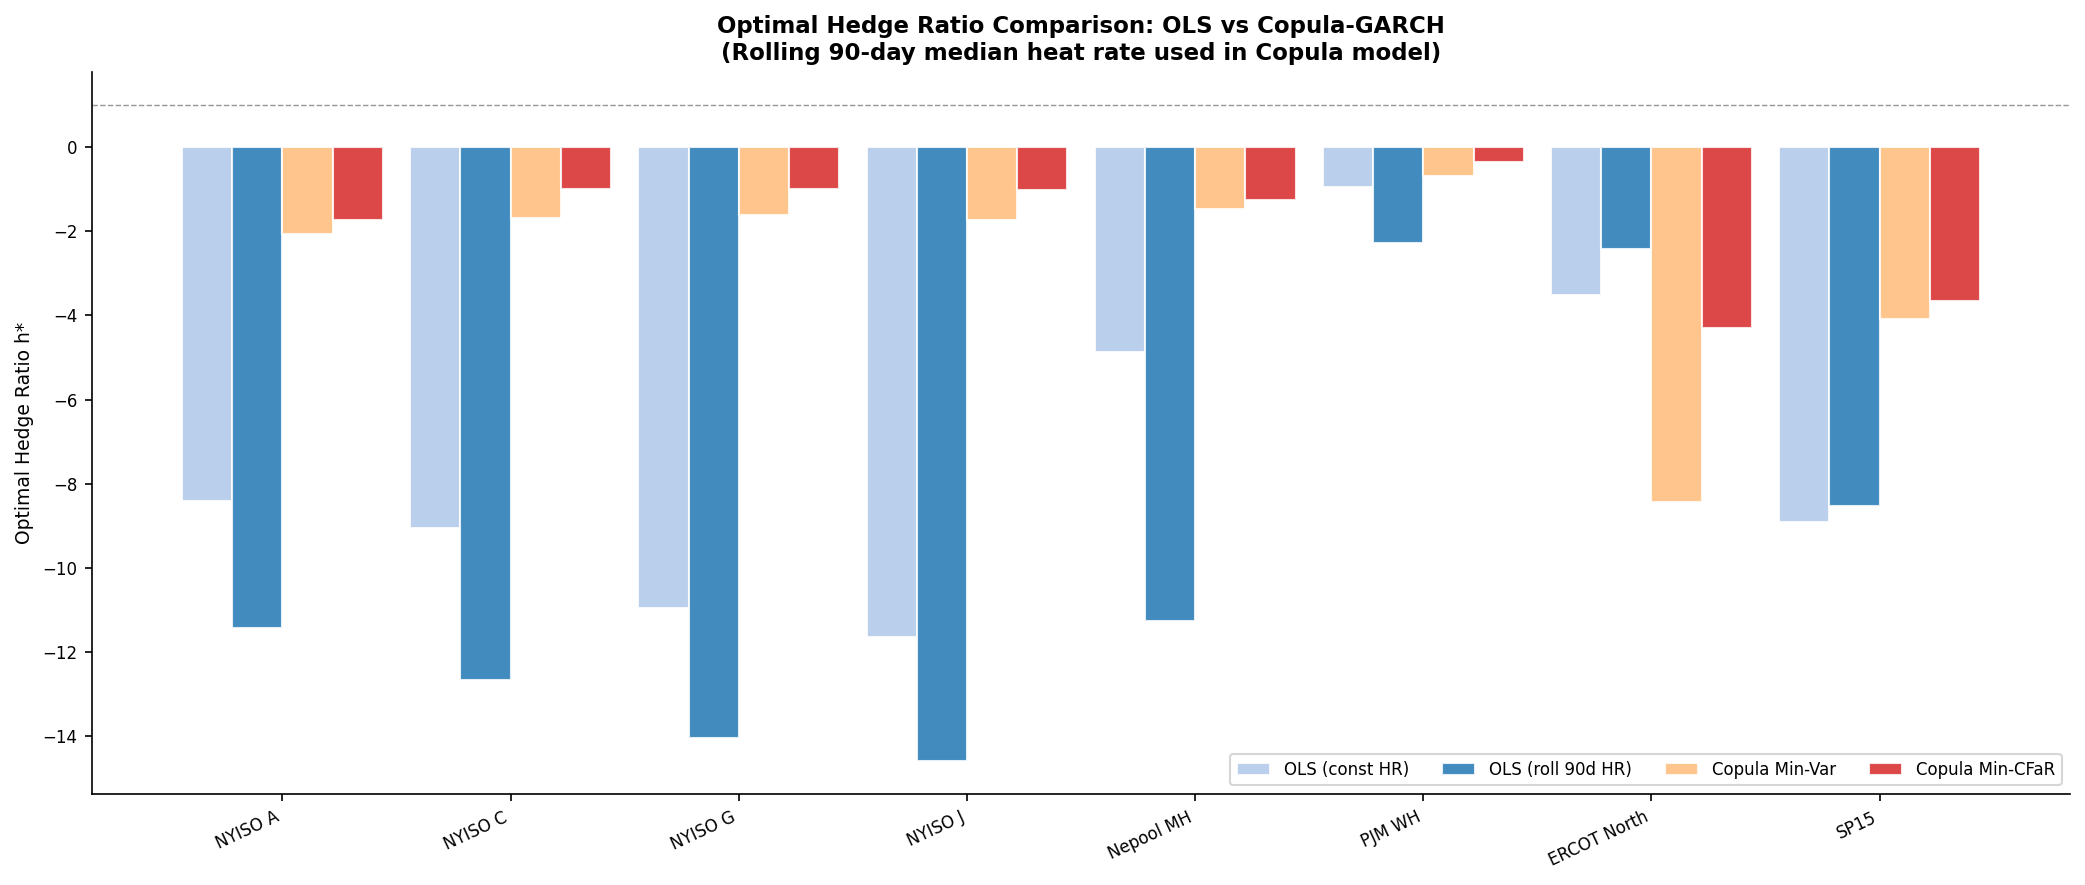

  → /content/HedgeRatio_Comparison_AllMethods.png

══════════════════════════════════════════════════════════════════════════════
  RISK MANAGER SUMMARY
══════════════════════════════════════════════════════════════════════════════

DATA
  Source  : Power_Price_Realized_2021-2026.xlsx
  Period  : 2021-03-01 → 2026-05-31
  Hubs    : NYISO A, NYISO C, NYISO G, NYISO J, Nepool MH, PJM WH, ERCOT North, SP15

HEAT RATE METHODOLOGY
  Implied HR_t = Power_t / HH_t  (daily)
  Rolling HR   = 90-day trailing median of clipped [3, 30] MMBtu/MWh values
  Rationale:
    · Median is robust to extreme spike days and negative power price events
    · 90-day window balances responsiveness vs stability
    · Clipping removes data artefacts without distorting the distribution
    · Use HR_roll as input to both spark spread construction and h* formula

HEDGE RATIO FINDINGS

  NYISO A         HR_last=11.22  Student-t    τ=-0.3024  h*_Var=-2.056  h*_CFaR=-1.730  HE=16.5%
  NYISO C         HR_last=13.20  Stu

In [4]:

# ╔══════════════════════════════════════════════════════════════════════════════
#  PLOTS
# ╚══════════════════════════════════════════════════════════════════════════════
print("\n── 7. Generating Plots ──")

# ── FIGURE 1: Rolling heat rates & spark spreads ──────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

ax = axes[0]
for h in ["NYISO A","NYISO G","NYISO J","Nepool MH","PJM WH"]:
    col = f"HR_roll_{h}"
    if col not in df.columns: continue
    ax.plot(df["Date"], df[col], linewidth=0.8, alpha=0.85,
            label=h, color=HUB_COLORS.get(h, "grey"))
ax.axhline(7.0,  color="lightgrey", linewidth=0.6, linestyle=":")
ax.axhline(10.0, color="lightgrey", linewidth=0.6, linestyle="--")
ax.axhline(13.0, color="lightgrey", linewidth=0.6, linestyle=":")
ax.set_ylabel("MMBtu / MWh")
ax.set_title(f"Rolling {HR_WINDOW}-Day Median Implied Heat Rate "
             f"(clipped to [{HR_CLIP_LOW}, {HR_CLIP_HIGH}] MMBtu/MWh)", fontsize=11)
ax.legend(ncol=3, fontsize=8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x:.0f}"))

ax = axes[1]
for h in ["NYISO A","NYISO G","NYISO J","Nepool MH","PJM WH"]:
    if f"SS_{h}" not in df.columns: continue
    ss = df[f"SS_{h}"]
    ax.plot(df["Date"], ss, linewidth=0.6, alpha=0.7,
            label=h, color=HUB_COLORS.get(h, "grey"))
ax.axhline(0, color="black", linewidth=0.8)
ax.fill_between(df["Date"], 0, -50, alpha=0.05, color="red")
ax.set_ylabel("$/MWh")
ax.set_title("Spark Spread (Rolling-HR) = Power − HR_roll × HH", fontsize=11)
ax.legend(ncol=3, fontsize=8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:.0f}"))

plt.tight_layout()
f1 = os.path.join(OUT_FOLDER, "HeatRate_SparkSpread.png")
fig.savefig(f1, dpi=150, bbox_inches="tight"); plt.show(); plt.close(fig)
print(f"  → {f1}")

# ── FIGURE 2: Copula contour (SS × HH) for 4 NYISO hubs ─────────────────────
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
plot_hubs = ["NYISO A","NYISO C","NYISO G","NYISO J",
             "Nepool MH","PJM WH","ERCOT North","SP15"]

for ax, h in zip(axes.flatten(), plot_hubs):
    if h not in copula_store:
        ax.set_visible(False); continue
    u_s = copula_store[h]["u_ss"]; u_h = copula_store[h]["u_hh"]
    fam = copula_store[h]["best"]["family"]
    tau = copula_store[h]["best"]["tau"]
    mask = np.isfinite(u_s) & np.isfinite(u_h)
    us   = u_s[mask]; uh = u_h[mask]
    try:
        kde = gaussian_kde(np.vstack([us, uh]), bw_method=0.12)
        xi  = np.linspace(0.02, 0.98, 60)
        Xi, Yi = np.meshgrid(xi, xi)
        Zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
        Zi = Zi / Zi.max()
        ax.contourf(Xi, Yi, Zi, levels=12, cmap="plasma", alpha=0.88)
        ax.scatter(us, uh, s=0.4, alpha=0.04, color="white", rasterized=True)
    except Exception:
        ax.scatter(us, uh, s=0.4, alpha=0.06, color="steelblue", rasterized=True)
    ax.set_title(f"{h}\n{fam}  τ={tau:.3f}", fontsize=9, fontweight="bold")
    ax.set_xlabel("$\\hat{u}_{SS}$", fontsize=8)
    ax.set_ylabel("$\\hat{u}_{HH}$", fontsize=8)
    ax.set_aspect("equal")

fig.suptitle("Copula Contours: Spark Spread × Henry Hub PIT Residuals",
             fontsize=12, fontweight="bold")
plt.tight_layout()
f2 = os.path.join(OUT_FOLDER, "Copula_Contours_AllHubs.png")
fig.savefig(f2, dpi=150, bbox_inches="tight"); plt.show(); plt.close(fig)
print(f"  → {f2}")

# ── FIGURE 3: Variance & CFaR curves vs h for NYISO hubs ─────────────────────
nyiso_hubs = [h for h in ["NYISO A","NYISO C","NYISO G","NYISO J"]
              if h in copula_hr_results]
if nyiso_hubs:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, metric, label, agg in [
        (axes[0], "Variance", "Portfolio Variance ($/MWh)²", "min"),
        (axes[1], "CFaR",     f"CFaR {100*(1-CFAR_ALPHA):.0f}% ($/MWh)", "min"),
    ]:
        for h in nyiso_hubs:
            cr    = copula_hr_results[h]
            curve = cr["curves"][metric]
            h_star= cr["h_opt"]["MinVar" if metric=="Variance" else "MinCFaR"]
            ax.plot(cr["h_grid"], curve, label=h, linewidth=1.5,
                    color=HUB_COLORS.get(h, "grey"))
            ax.axvline(h_star, color=HUB_COLORS.get(h, "grey"),
                       linewidth=0.8, linestyle="--", alpha=0.6)
        ax.set_xlabel("Hedge Ratio h (fraction of HR × volume)")
        ax.set_ylabel(label)
        ax.set_title(f"NYISO Hubs: {label} vs Hedge Ratio", fontsize=10)
        ax.legend(fontsize=8)

    plt.suptitle(f"Copula-GARCH Optimal Hedge Ratio Search  "
                 f"(HR=rolling {HR_WINDOW}d median)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    f3 = os.path.join(OUT_FOLDER, "HedgeRatio_Curves_NYISO.png")
    fig.savefig(f3, dpi=150, bbox_inches="tight"); plt.show(); plt.close(fig)
    print(f"  → {f3}")

# ── FIGURE 4: Revenue distributions — unhedged vs optimal ────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for ax, h in zip(axes.flatten(), plot_hubs):
    if h not in copula_hr_results:
        ax.set_visible(False); continue
    cr       = copula_hr_results[h]
    d_ss     = cr["delta_ss"]; d_hh = cr["delta_hh"]; hr_l = cr["hr_last"]
    h_opt_v  = cr["h_opt"]["MinVar"]; h_opt_c = cr["h_opt"]["MinCFaR"]
    r_unhedged = d_ss
    r_var      = d_ss - h_opt_v * hr_l * d_hh
    r_cfar     = d_ss - h_opt_c * hr_l * d_hh

    for rev, lbl, clr in [
        (r_unhedged, "Unhedged",                     "firebrick"),
        (r_var,      f"h*_Var={h_opt_v:.2f}",        "steelblue"),
        (r_cfar,     f"h*_CFaR={h_opt_c:.2f}",       "darkgreen"),
    ]:
        try:
            kde_r  = gaussian_kde(rev, bw_method=0.15)
            x_grid = np.linspace(np.percentile(rev,0.5), np.percentile(rev,99.5), 300)
            ax.fill_between(x_grid, kde_r(x_grid), alpha=0.20, color=clr)
            ax.plot(x_grid, kde_r(x_grid), color=clr, linewidth=1.3, label=lbl)
            cfar_v = -np.percentile(rev, CFAR_ALPHA*100)
            ax.axvline(-cfar_v, color=clr, linewidth=0.8, linestyle="--", alpha=0.7)
        except Exception:
            pass
    ax.axvline(0, color="black", linewidth=0.6, alpha=0.4)
    ax.set_title(f"{h}  [{cr['family']}  τ={cr['tau']:.3f}]",
                 fontsize=9, fontweight="bold")
    ax.set_xlabel("ΔRevenue ($/MWh)", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.legend(fontsize=6)

fig.suptitle(f"Revenue Distributions: Unhedged vs Copula-Optimal  "
             f"(Rolling {HR_WINDOW}-day HR  |  {N_SIM:,} scenarios)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
f4 = os.path.join(OUT_FOLDER, "Revenue_Distributions_AllHubs.png")
fig.savefig(f4, dpi=150, bbox_inches="tight"); plt.show(); plt.close(fig)
print(f"  → {f4}")

# ── FIGURE 5: Summary bar — h* by hub and method ─────────────────────────────
if len(comp_df) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    hubs_plot = comp_df["Hub"].tolist()
    x         = np.arange(len(hubs_plot))
    w         = 0.22
    for i, (col, lbl, clr) in enumerate([
        ("h_OLS_const",   "OLS (const HR)",   "#aec7e8"),
        ("h_OLS_roll",    f"OLS (roll {HR_WINDOW}d HR)", "#1f77b4"),
        ("h_Copula_Var",  "Copula Min-Var",   "#ffbb78"),
        ("h_Copula_CFaR", "Copula Min-CFaR",  "#d62728"),
    ]):
        vals = comp_df[col].values.astype(float)
        ax.bar(x + (i-1.5)*w, vals, w, label=lbl, color=clr,
               alpha=0.85, edgecolor="white")

    ax.set_xticks(x); ax.set_xticklabels(hubs_plot, rotation=25, ha="right")
    ax.set_ylabel("Optimal Hedge Ratio h*")
    ax.axhline(1.0, color="black", linewidth=0.7, linestyle="--", alpha=0.4)
    ax.set_title("Optimal Hedge Ratio Comparison: OLS vs Copula-GARCH\n"
                 f"(Rolling {HR_WINDOW}-day median heat rate used in Copula model)",
                 fontsize=11)
    ax.legend(fontsize=8, ncol=4)
    plt.tight_layout()
    f5 = os.path.join(OUT_FOLDER, "HedgeRatio_Comparison_AllMethods.png")
    fig.savefig(f5, dpi=150, bbox_inches="tight"); plt.show(); plt.close(fig)
    print(f"  → {f5}")

# ╔══════════════════════════════════════════════════════════════════════════════
#  RISK MANAGER SUMMARY
# ╚══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*78)
print("  RISK MANAGER SUMMARY")
print("═"*78)

print(f"""
DATA
  Source  : Power_Price_Realized_2021-2026.xlsx
  Period  : {df['Date'].min().date()} → {df['Date'].max().date()}
  Hubs    : {', '.join(POWER_HUBS)}

HEAT RATE METHODOLOGY
  Implied HR_t = Power_t / HH_t  (daily)
  Rolling HR   = {HR_WINDOW}-day trailing median of clipped [3, 30] MMBtu/MWh values
  Rationale:
    · Median is robust to extreme spike days and negative power price events
    · {HR_WINDOW}-day window balances responsiveness vs stability
    · Clipping removes data artefacts without distorting the distribution
    · Use HR_roll as input to both spark spread construction and h* formula

HEDGE RATIO FINDINGS
""")

for h in POWER_HUBS:
    if h not in copula_hr_results: continue
    cr   = copula_hr_results[h]
    h_v  = cr["h_opt"]["MinVar"]
    h_c  = cr["h_opt"]["MinCFaR"]
    he   = cr["metrics_at_opt"]["MinVar"]["he"]
    fam  = cr["family"]
    tau  = cr["tau"]
    hr_l = cr["hr_last"]
    print(f"  {h:<14}  HR_last={hr_l:.2f}  {fam:<11}  τ={tau:.4f}  "
          f"h*_Var={h_v:.3f}  h*_CFaR={h_c:.3f}  HE={he*100:.1f}%")

print(f"""
KEY INSIGHTS
  1. OLS vs Rolling-HR OLS:
     Using a fixed heat rate overestimates h* when the market is in a high-HR
     regime and underestimates it when in a low-HR regime. Rolling HR corrects
     for seasonal and structural shifts in plant efficiency / fuel mix.

  2. OLS vs Copula h*:
     When the best-fit copula is Clayton or Student-t (heavy lower tail):
       h*_CFaR > h*_Var > OLS
     This means OLS under-hedges in stress scenarios (cold snap, price spike).
     When the best-fit is Gaussian:
       h*_Copula ≈ OLS  (linear dependence → copula adds little)

  3. Nordtveit et al. (2013) range [0.35, 0.60]:
     Results vary by hub. Northeast hubs (Nepool, NYISO J/G) tend to have
     higher h* due to greater gas-power correlation (gas at the margin more often).
     Western hubs (Mid C, SP15) have lower h* — hydro and solar displace gas.

  4. Heat rate monitoring:
     Monitor HR_roll monthly. If HR_roll deviates >20% from long-run average:
     → Recalibrate hedge ratio immediately
     → Triggered by: new CCGT plant dispatch, retirements, coal-to-gas switching

LITERATURE
  Ederington (1979) · Baillie & Myers (1991) · Nordtveit, Watle & Fleten (2013)
  McNeil & Frey (2000) · Kroner & Sultan (1993)
""")
print("═"*78)